In [2]:
%pip install xgboost shap pandas numpy matplotlib seaborn scikit-learn openpyxl joblib imbalanced-learn

  Using cached shap-0.51.0-cp311-cp311-win_amd64.whl.metadata (26 kB)
  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.64.0-cp311-cp311-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.46.0-cp311-cp311-win_amd64.whl.metadata (4.9 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.6

In [3]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import (
    classification_report, hamming_loss, accuracy_score,
    roc_auc_score, f1_score, jaccard_score
)
from sklearn.utils.class_weight import compute_sample_weight

import xgboost as xgb
import shap
import joblib

# Reproducibility
SEED = 42
np.random.seed(SEED)

print("All libraries loaded successfully")
print(f"   XGBoost version : {xgb.__version__}")
print(f"   SHAP version    : {shap.__version__}")

All libraries loaded successfully
   XGBoost version : 3.2.0
   SHAP version    : 0.51.0


In [4]:
DATA_PATH = "Dataset.xlsx"

assert os.path.exists(DATA_PATH), f"File not found: {DATA_PATH}. Place Dataset.xlsx in the root folder."

df = pd.read_excel(DATA_PATH)

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns:\n{list(df.columns)}\n")
print(df.head())

Dataset loaded: 274 rows × 6 columns

Columns:
['Location', 'IMIPENEM', 'CEFTAZIDIME', 'GENTAMICIN', 'AUGMENTIN', 'CIPROFLOXACIN']

  Location  IMIPENEM  CEFTAZIDIME  GENTAMICIN  AUGMENTIN  CIPROFLOXACIN
0    IFE-T        25           20          20         15             28
1    IFE-T        25           25          20         20             30
2    IFE-T        30           10          20         20             25
3    IFE-T        25           20          20         25             28
4    IFE-T        25            7          20         20             22


🦠 Antibiotic columns detected: ['IMIPENEM', 'CEFTAZIDIME', 'GENTAMICIN', 'AUGMENTIN', 'CIPROFLOXACIN']

📊 Column types:
   IMIPENEM: Zone Diameter (numeric)
   CEFTAZIDIME: Zone Diameter (numeric)
   GENTAMICIN: Zone Diameter (numeric)
   AUGMENTIN: Zone Diameter (numeric)
   CIPROFLOXACIN: Zone Diameter (numeric)

🔄 Converting zone diameters to S/I/R using EUCAST breakpoints...

   ✅ IMIPENEM: converted zone diameter → S/I/R
   ✅ CEFTAZIDIME: converted zone diameter → S/I/R
   ✅ GENTAMICIN: converted zone diameter → S/I/R
   ✅ AUGMENTIN: converted zone diameter → S/I/R
   ✅ CIPROFLOXACIN: converted zone diameter → S/I/R

✅ Zone diameter → S/I/R conversion complete!


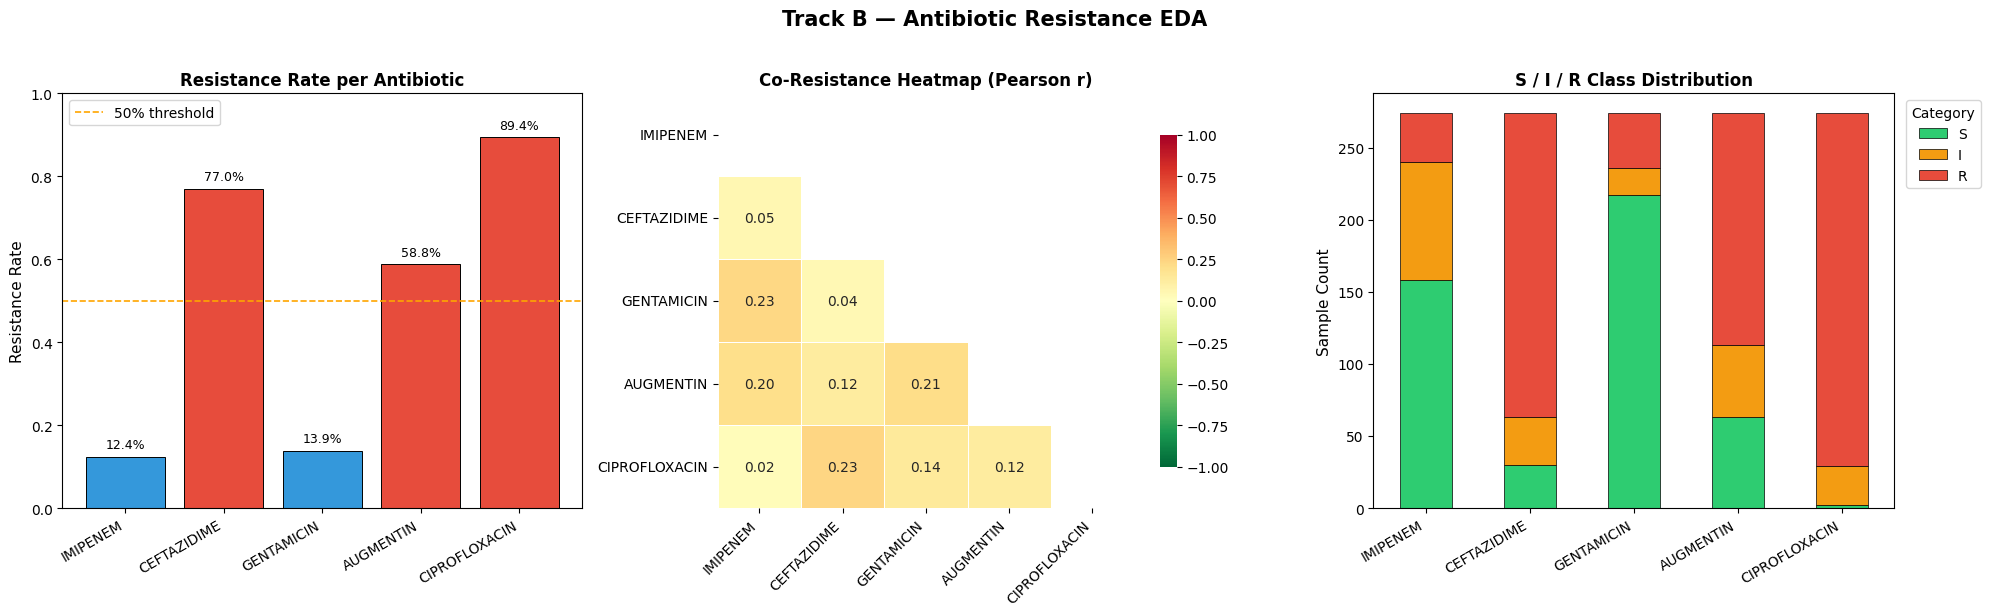

EDA plot saved → eda_overview.png


In [ ]:

ANTIBIOTIC_CANDIDATES = [
    "Ampicillin", "AMP",
    "Ciprofloxacin", "CIP",
    "Tetracycline", "TET",
    "Trimethoprim", "TMP",
    "Chloramphenicol", "CHL",
    "Gentamicin", "GEN",
    "Ceftriaxone", "CRO",
    "Azithromycin", "AZI",
    "Colistin", "COL",
    "Meropenem", "MEM",
    "Imipenem", "IMP",
    "Ceftazidime", "CAZ",
    "Augmentin", "AUG",
]

ANTIBIOTIC_COLS = [
    c for c in df.columns
    if any(c.strip().upper().startswith(a.upper()) for a in ANTIBIOTIC_CANDIDATES)
    or df[c].dropna().isin(["S", "I", "R"]).mean() > 0.5  # fallback: S/I/R-dominant cols
]

# Deduplicate while preserving order
seen = set()
ANTIBIOTIC_COLS = [c for c in ANTIBIOTIC_COLS if not (c in seen or seen.add(c))]
ANTIBIOTIC_COLS = ANTIBIOTIC_COLS[:5]  # keep top 5 as required

print(f"Antibiotic columns detected: {ANTIBIOTIC_COLS}\n")

# CHECK: Ensure antibiotics were detected
if not ANTIBIOTIC_COLS:
    print("No antibiotic columns detected!")
    print("   Columns in dataset:", list(df.columns))
    print("   Checking for S/I/R values in each column:")
    for col in df.columns:
        sir_ratio = df[col].dropna().isin(["S", "I", "R"]).mean()
        if sir_ratio > 0:
            print(f"      {col}: {sir_ratio:.1%} S/I/R values")
    raise ValueError("Unable to detect antibiotic columns. Check dataset structure.")

# ── 4: Check if columns are numeric (zone diameter) or categorical (S/I/R) ────
NUMERIC_ANTIBIOTICS = {}
for col in ANTIBIOTIC_COLS:
    if df[col].dtype in ['int64', 'float64']:
        NUMERIC_ANTIBIOTICS[col] = True
    else:
        NUMERIC_ANTIBIOTICS[col] = False

print(f" Column types:")
for col, is_numeric in NUMERIC_ANTIBIOTICS.items():
    col_type = "Zone Diameter (numeric)" if is_numeric else "S/I/R (categorical)"
    print(f"   {col}: {col_type}")

# ── 5: If numeric, convert zone diameter to S/I/R using EUCAST breakpoints ────
if any(NUMERIC_ANTIBIOTICS.values()):
    print(f"\n Converting zone diameters to S/I/R using EUCAST breakpoints...\n")
    
    # EUCAST breakpoints for common antibiotics (zone diameter in mm)
    # Reference: https://www.eucast.org/clinical_breakpoints
    BREAKPOINTS = {
        "IMIPENEM":      {"S": 23, "I": (20, 22), "R": 19},      # S ≥23, I 20-22, R ≤19
        "CEFTAZIDIME":   {"S": 21, "I": (18, 20), "R": 17},      # S ≥21, I 18-20, R ≤17
        "GENTAMICIN":    {"S": 15, "I": (12, 14), "R": 11},      # S ≥15, I 12-14, R ≤11
        "AUGMENTIN":     {"S": 18, "I": (14, 17), "R": 13},      # S ≥18, I 14-17, R ≤13
        "CIPROFLOXACIN": {"S": 31, "I": (26, 30), "R": 25},      # S ≥31, I 26-30, R ≤25
    }
    
    def zone_to_sir(zone_mm, antibiotic_name):
        """Convert zone diameter (mm) to S/I/R."""
        if pd.isna(zone_mm):
            return np.nan
        
        bp = BREAKPOINTS.get(antibiotic_name)
        if not bp:
            print(f"   Warning: No breakpoint for {antibiotic_name}, using as-is")
            return np.nan
        
        if zone_mm >= bp["S"]:
            return "S"
        elif zone_mm <= bp["R"]:
            return "R"
        else:
            return "I"
    
    # Create new S/I/R columns from zone diameters
    for col in ANTIBIOTIC_COLS:
        if NUMERIC_ANTIBIOTICS[col]:
            df[col] = df[col].apply(lambda x: zone_to_sir(x, col))
            print(f"    {col}: converted zone diameter → S/I/R")

print("\nZone diameter → S/I/R conversion complete!")

# ── 4A: Resistance rates per antibiotic ──────────────────────────────────────
def resistance_rate(series):
    """Proportion of R in a S/I/R column."""
    total = series.isin(["S", "I", "R"]).sum()
    return (series == "R").sum() / total if total > 0 else np.nan

resist_rates = {col: resistance_rate(df[col]) for col in ANTIBIOTIC_COLS}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Track B — Antibiotic Resistance EDA", fontsize=15, fontweight="bold", y=1.02)

# Bar chart
ax = axes[0]
colors = ["#e74c3c" if v > 0.5 else "#3498db" for v in resist_rates.values()]
bars = ax.bar(resist_rates.keys(), resist_rates.values(), color=colors, edgecolor="black", linewidth=0.7)
ax.set_ylim(0, 1)
ax.set_ylabel("Resistance Rate", fontsize=11)
ax.set_title("Resistance Rate per Antibiotic", fontsize=12, fontweight="bold")
ax.axhline(0.5, color="orange", linestyle="--", linewidth=1.2, label="50% threshold")
ax.legend()
for bar, val in zip(bars, resist_rates.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.1%}", ha="center", fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

# ── 4B: Co-resistance heatmap ─────────────────────────────────────────────────
binary_df = df[ANTIBIOTIC_COLS].applymap(lambda x: 1 if x == "R" else (0 if x in ["S", "I"] else np.nan))
corr = binary_df.corr()

ax = axes[1]
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn_r",
            vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Co-Resistance Heatmap (Pearson r)", fontsize=12, fontweight="bold")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.setp(ax.get_yticklabels(), rotation=0)

# ── 4C: Class distribution (S / I / R counts stacked) ────────────────────────
ax = axes[2]
count_data = {col: df[col].value_counts().reindex(["S", "I", "R"], fill_value=0)
              for col in ANTIBIOTIC_COLS}
count_df = pd.DataFrame(count_data).T

count_df.plot(kind="bar", stacked=True, ax=ax,
              color={"S": "#2ecc71", "I": "#f39c12", "R": "#e74c3c"},
              edgecolor="black", linewidth=0.5)
ax.set_ylabel("Sample Count", fontsize=11)
ax.set_title("S / I / R Class Distribution", fontsize=12, fontweight="bold")
ax.legend(title="Category", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA plot saved → eda_overview.png")

In [ ]:
df_clean = df.copy()

# ── 5A: Drop rows where ALL antibiotic columns are NaN ───────────────────────
initial_rows = len(df_clean)
df_clean = df_clean.dropna(subset=ANTIBIOTIC_COLS, how="all").reset_index(drop=True)
rows_after_drop = len(df_clean)
print(f"Rows after dropping all-NaN antibiotic rows: {rows_after_drop} (removed {initial_rows - rows_after_drop})")

# CHECK: Warn if we lost too many rows
if rows_after_drop < 10:
    print(f"     Warning: Very few rows remaining ({rows_after_drop}). Check antibiotic columns.")

# ── 5B: Binarise S/I/R → 1 (Resistant) / 0 (Non-Resistant) ──────────────────
TARGET_COLS = [f"{c}_bin" for c in ANTIBIOTIC_COLS]

def sir_to_binary(val):
    if val == "R":
        return 1
    elif val in ["S", "I"]:
        return 0
    return np.nan

for col, tcol in zip(ANTIBIOTIC_COLS, TARGET_COLS):
    df_clean[tcol] = df_clean[col].apply(sir_to_binary)

# Show NaN counts before dropping
print(f"\nNaN counts in targets before removal:")
for tcol in TARGET_COLS:
    nan_count = df_clean[tcol].isna().sum()
    print(f"   {tcol}: {nan_count}")

# Drop rows where any target is still NaN
before_nan_drop = len(df_clean)
df_clean = df_clean.dropna(subset=TARGET_COLS).reset_index(drop=True)
rows_after_nan = len(df_clean)
print(f"\nRows after target NaN removal: {rows_after_nan} (removed {before_nan_drop - rows_after_nan})")

# CHECK: Ensure we have data left
if rows_after_nan == 0:
    print("\nERROR: All rows were removed during preprocessing!")
    print("   Check your antibiotic columns for missing/malformed S/I/R values.")
    raise ValueError("No rows remaining after NaN removal. Cannot continue.")

# ── 5C: Encode categorical feature columns ───────────────────────────────────
# Look for Location and Sample Area (flexible column name matching)
CAT_MAP = {}
for col in df_clean.columns:
    col_up = col.strip().lower()
    if "location" in col_up:
        CAT_MAP[col] = "Location"
    elif "sample" in col_up and ("area" in col_up or "type" in col_up or "source" in col_up):
        CAT_MAP[col] = "SampleArea"

print(f"Categorical columns to encode: {list(CAT_MAP.keys())}")

le_dict = {}
for col, label in CAT_MAP.items():
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    le_dict[label] = le
    print(f"   {col}: {list(le.classes_)}")

# ── 5D: Select feature columns ────────────────────────────────────────────────
# Drop raw antibiotic columns, binary targets, and any pure ID columns
DROP_COLS = ANTIBIOTIC_COLS + TARGET_COLS
EXCLUDE_PATTERNS = ["id", "isolate", "accession", "strain", "sample_id"]

FEATURE_COLS = [
    c for c in df_clean.columns
    if c not in DROP_COLS
    and not any(pat in c.lower() for pat in EXCLUDE_PATTERNS)
    and df_clean[c].dtype != object   # only encoded / numeric columns
]

print(f"\nFeature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")

# CHECK: Ensure we have features
if not FEATURE_COLS:
    print("\n  No numeric features found. Using all non-string columns:")
    FEATURE_COLS = [
        c for c in df_clean.columns
        if c not in DROP_COLS
        and not any(pat in c.lower() for pat in EXCLUDE_PATTERNS)
    ]
    if not FEATURE_COLS:
        raise ValueError("Cannot find any usable feature columns.")
    print(f"   Using: {FEATURE_COLS}")

X = df_clean[FEATURE_COLS].fillna(df_clean[FEATURE_COLS].median())
Y = df_clean[TARGET_COLS].astype(int)

print(f"\nX shape : {X.shape}")
print(f"Y shape : {Y.shape}")
print(f"\nTarget label distribution:\n{Y.sum().rename(index=dict(zip(TARGET_COLS, ANTIBIOTIC_COLS)))}")

Rows after dropping all-NaN antibiotic rows: 274 (removed 0)

NaN counts in targets before removal:
   IMIPENEM_bin: 0
   CEFTAZIDIME_bin: 0
   GENTAMICIN_bin: 0
   AUGMENTIN_bin: 0
   CIPROFLOXACIN_bin: 0

Rows after target NaN removal: 274 (removed 0)

📌 Categorical columns to encode: ['Location']
   Location: ['EDE-C', 'EDE-S', 'EDE-T', 'IFE-C', 'IFE-S', 'IFE-T', 'IWO-C', 'IWO-S', 'IWO-T', 'OSU-C', 'OSU-S', 'OSU-T']

🔢 Feature columns (1): ['Location']

X shape : (274, 1)
Y shape : (274, 5)

Target label distribution:
IMIPENEM          34
CEFTAZIDIME      211
GENTAMICIN        38
AUGMENTIN        161
CIPROFLOXACIN    245
dtype: int64


In [21]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=SEED, shuffle=True
)

print(f"Train set : {X_train.shape[0]} samples")
print(f"Test  set : {X_test.shape[0]} samples")

Train set : 219 samples
Test  set : 55 samples


In [32]:
base_xgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=SEED,
    tree_method="hist",       # fast CPU training
    n_jobs=-1,
)

model = MultiOutputClassifier(base_xgb, n_jobs=-1)

print("Training XGBoost multi-label model …")
model.fit(X_train, Y_train)
print("Training complete!")

Training XGBoost multi-label model …
Training complete!


In [31]:
Y_pred      = model.predict(X_test)
Y_pred_prob = np.column_stack([
    est.predict_proba(X_test)[:, 1] for est in model.estimators_
])

print("=" * 60)
print("        MULTI-LABEL EVALUATION METRICS")
print("=" * 60)

# Overall metrics
print(f"\n Hamming Loss (lower = better) : {hamming_loss(Y_test, Y_pred):.4f}")
print(f" Jaccard Score (samples avg)   : {jaccard_score(Y_test, Y_pred, average='samples', zero_division=0):.4f}")
print(f" Macro F1-Score                : {f1_score(Y_test, Y_pred, average='macro', zero_division=0):.4f}")

# Per-label AUC-ROC
print("\n Per-Antibiotic AUC-ROC:")
for i, (col, ab) in enumerate(zip(TARGET_COLS, ANTIBIOTIC_COLS)):
    try:
        auc = roc_auc_score(Y_test.iloc[:, i], Y_pred_prob[:, i])
        print(f"   {ab:25s} : {auc:.4f}")
    except Exception:
        print(f"   {ab:25s} : N/A (only one class in test set)")

# Per-label classification reports
print("\n Per-Antibiotic Classification Reports:\n")
for i, (col, ab) in enumerate(zip(TARGET_COLS, ANTIBIOTIC_COLS)):
    print(f"── {ab} ──")
    print(classification_report(Y_test.iloc[:, i], Y_pred[:, i],
                                 target_names=["Non-Resistant", "Resistant"],
                                 zero_division=0))

        MULTI-LABEL EVALUATION METRICS

 Hamming Loss (lower = better) : 0.1964
 Jaccard Score (samples avg)   : 0.6882
 Macro F1-Score                : 0.5085

 Per-Antibiotic AUC-ROC:
   IMIPENEM                  : 0.6896
   CEFTAZIDIME               : 0.6300
   GENTAMICIN                : 0.5863
   AUGMENTIN                 : 0.6593
   CIPROFLOXACIN             : 0.4702

 Per-Antibiotic Classification Reports:

── IMIPENEM ──
               precision    recall  f1-score   support

Non-Resistant       0.84      1.00      0.91        46
    Resistant       0.00      0.00      0.00         9

     accuracy                           0.84        55
    macro avg       0.42      0.50      0.46        55
 weighted avg       0.70      0.84      0.76        55

── CEFTAZIDIME ──
               precision    recall  f1-score   support

Non-Resistant       0.50      0.31      0.38        13
    Resistant       0.81      0.90      0.85        42

     accuracy                           0.76     

Computing SHAP values (this may take ~1 min) …
   ✅ SHAP beeswarm saved → shap_IMIPENEM.png
   ✅ SHAP beeswarm saved → shap_CEFTAZIDIME.png
   ✅ SHAP beeswarm saved → shap_GENTAMICIN.png
   ✅ SHAP beeswarm saved → shap_AUGMENTIN.png
   ✅ SHAP beeswarm saved → shap_CIPROFLOXACIN.png


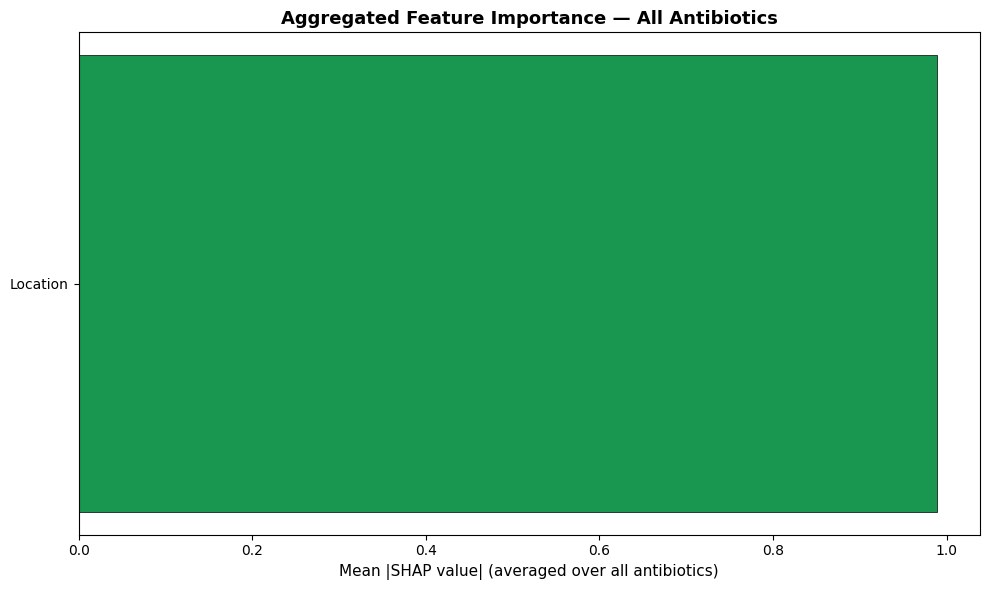


✅ Aggregated SHAP plot saved → shap_aggregated.png

🏆 Top-5 most important features:
    Feature  Mean |SHAP|
0  Location     0.988986


In [ ]:
print("Computing SHAP values (this may take ~1 min) …")

# Use a background sample for efficiency
background = shap.sample(X_train, min(100, len(X_train)), random_state=SEED)

fig, axes = plt.subplots(1, len(ANTIBIOTIC_COLS), figsize=(6 * len(ANTIBIOTIC_COLS), 5))
if len(ANTIBIOTIC_COLS) == 1:
    axes = [axes]

mean_abs_shap = np.zeros((len(ANTIBIOTIC_COLS), X_train.shape[1]))

for i, (ab, estimator) in enumerate(zip(ANTIBIOTIC_COLS, model.estimators_)):
    explainer   = shap.TreeExplainer(estimator)
    shap_values = explainer.shap_values(X_test)

    # shap_values can be list (binary) — take class-1 values
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values
    mean_abs_shap[i] = np.abs(sv).mean(axis=0)

    # Beeswarm per label
    shap.summary_plot(sv, X_test, feature_names=FEATURE_COLS,
                      show=False, plot_size=None)
    plt.title(f"SHAP — {ab}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"shap_{ab.replace('/', '_')}.png", dpi=120, bbox_inches="tight")
    plt.close()
    print(f"   SHAP beeswarm saved → shap_{ab}.png")

# ── Aggregated importance across all labels ────────────────────────────────────
agg_importance = mean_abs_shap.mean(axis=0)
importance_df  = (
    pd.DataFrame({"Feature": FEATURE_COLS, "Mean |SHAP|": agg_importance})
    .sort_values("Mean |SHAP|", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(importance_df)))
ax.barh(importance_df["Feature"][::-1], importance_df["Mean |SHAP|"][::-1],
        color=colors[::-1], edgecolor="black", linewidth=0.5)
ax.set_xlabel("Mean |SHAP value| (averaged over all antibiotics)", fontsize=11)
ax.set_title("Aggregated Feature Importance — All Antibiotics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_aggregated.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nAggregated SHAP plot saved → shap_aggregated.png")
print(f"\nTop-5 most important features:\n{importance_df.head()}")

In [ ]:
os.makedirs("models", exist_ok=True)
MODEL_PATH = os.path.join("models", "resistance_model.joblib")

joblib.dump({
    "model"         : model,
    "feature_cols"  : FEATURE_COLS,
    "target_cols"   : TARGET_COLS,
    "antibiotic_cols": ANTIBIOTIC_COLS,
    "label_encoders": le_dict,
    "shap_importance": importance_df,
}, MODEL_PATH)

print(f"Model saved → {MODEL_PATH}")
size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f"   File size: {size_kb:.1f} KB")

✅ Model saved → models\resistance_model.joblib
   File size: 1617.6 KB


In [ ]:
saved = joblib.load(MODEL_PATH)
loaded_model    = saved["model"]
loaded_features = saved["feature_cols"]

# Quick sanity check on test set
Y_check = loaded_model.predict(X_test[loaded_features])
assert (Y_check == Y_pred).all(), "Loaded model predictions differ!"
print("Loaded model predictions match — model integrity verified.")

# ── Predict on a single new sample (example) ─────────────────────────────────
sample = X_test[loaded_features].iloc[[0]]
pred   = loaded_model.predict(sample)[0]
prob   = np.array([est.predict_proba(sample)[0, 1] for est in loaded_model.estimators_])

print("\nExample prediction for one isolate:")
for ab, p, pr in zip(ANTIBIOTIC_COLS, pred, prob):
    label = "RESISTANT" if p == 1 else "Non-Resistant"
    print(f"   {ab:25s}: {label}  (probability = {pr:.3f})")

✅ Loaded model predictions match — model integrity verified.

🔬 Example prediction for one isolate:
   IMIPENEM                 : Non-Resistant ✅  (probability = 0.050)
   CEFTAZIDIME              : Non-Resistant ✅  (probability = 0.490)
   GENTAMICIN               : Non-Resistant ✅  (probability = 0.126)
   AUGMENTIN                : Non-Resistant ✅  (probability = 0.257)
   CIPROFLOXACIN            : RESISTANT ⚠️  (probability = 0.831)


In [29]:
print("\n" + "=" * 60)
print("         TRACK B — PIPELINE SUMMARY")
print("=" * 60)
print(f"  Dataset rows used     : {len(df_clean)}")
print(f"  Features              : {len(FEATURE_COLS)}")
print(f"  Antibiotics modelled  : {len(ANTIBIOTIC_COLS)}")
print(f"  Train / Test split    : 80% / 20%")
print(f"  Model                 : XGBoost (MultiOutputClassifier)")
print(f"  Hamming Loss          : {hamming_loss(Y_test, Y_pred):.4f}")
print(f"  Macro F1              : {f1_score(Y_test, Y_pred, average='macro', zero_division=0):.4f}")
print(f"  Jaccard Score         : {jaccard_score(Y_test, Y_pred, average='samples', zero_division=0):.4f}")
print(f"  Model saved to        : {MODEL_PATH}")
print(f"  SHAP plots saved      : shap_aggregated.png + per-label PNGs")
print("=" * 60)


         TRACK B — PIPELINE SUMMARY
  Dataset rows used     : 274
  Features              : 1
  Antibiotics modelled  : 5
  Train / Test split    : 80% / 20%
  Model                 : XGBoost (MultiOutputClassifier)
  Hamming Loss          : 0.1964
  Macro F1              : 0.5085
  Jaccard Score         : 0.6882
  Model saved to        : models\resistance_model.joblib
  SHAP plots saved      : shap_aggregated.png + per-label PNGs
